In [27]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

In [ ]:
df = sns.load_dataset("iris")
print(df.head())
print(df.shape)
print(df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [ ]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
df.groupby(['species']).mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [ ]:
df.groupby(['species']).std()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,0.352490,0.379064,0.173664,0.105386
versicolor,0.516171,0.313798,0.469911,0.197753
virginica,0.635880,0.322497,0.551895,0.274650


### Histograms with KDE for each variable

Let's visualize the distribution of each numerical variable using histograms combined with Kernel Density Estimates (KDE) to understand their shapes.

In [35]:
var_col = df.select_dtypes(include=['float64']).columns
df_long = df[var_col].melt(var_name="Variable", value_name='Value')
var_color = sns.color_palette("muted", n_colors=len(var_col))
palettes = dict(zip(var_col, var_color))

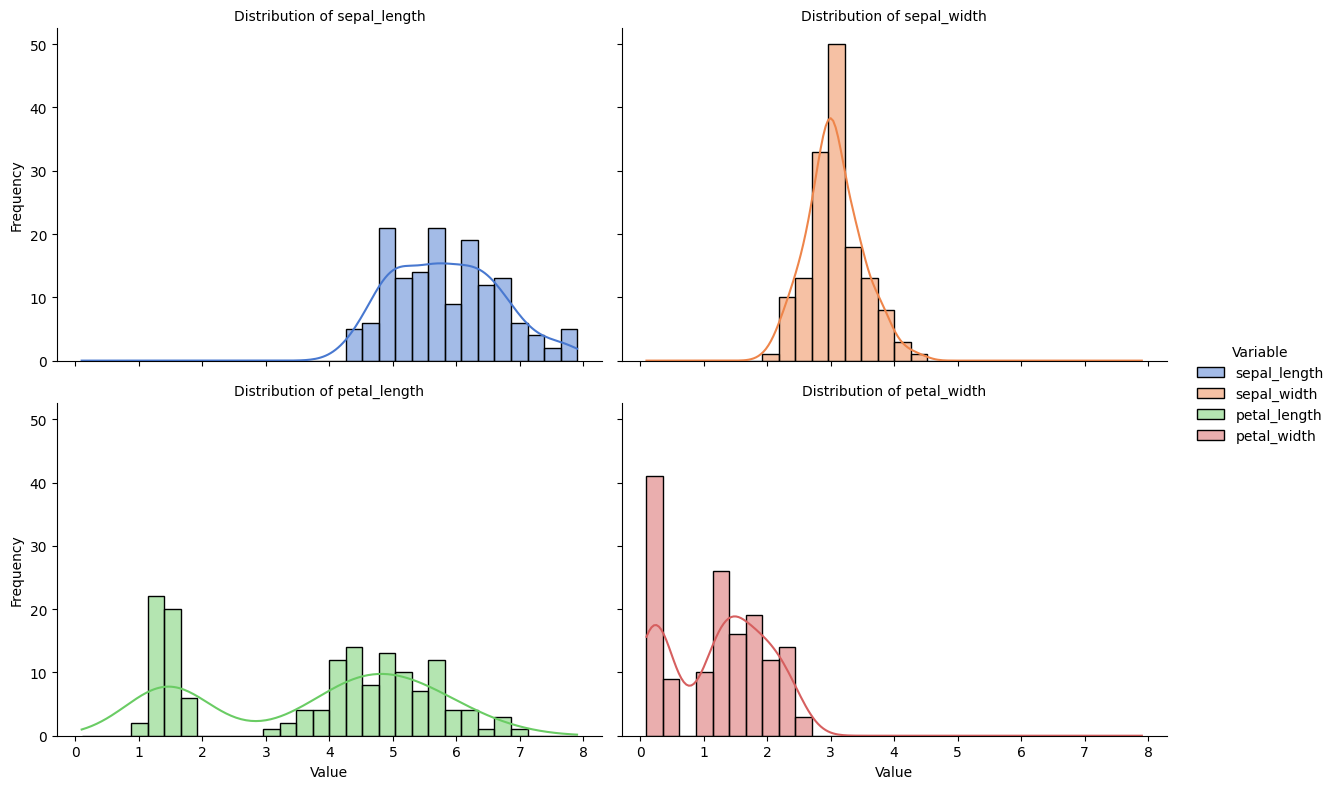

In [36]:
var_hist = sns.displot(
    data=df_long,
    x="Value",
    col="Variable",
    hue="Variable",
    col_wrap= int(np.ceil(np.sqrt(len(var_col)))),
    kind="hist",
    kde=True,
    palette=palettes,
    bins = 30,
    height=4,
    aspect=1.5,
)

var_hist.set_titles("Distribution of {col_name}")
var_hist.set_axis_labels("Value", "Frequency")
plt.show()

**Comment**:

Petal length and petal width appear to be bimodal (have two peaks).

Sepal length and sepal width generally show a normal-like distribution.

Sepal length exhibits a slight left skew, while petal width shows a slight right skew.

### Boxplots for each variable, grouped by species

Boxplots will help us visualize the distribution of each feature and compare them across different species.

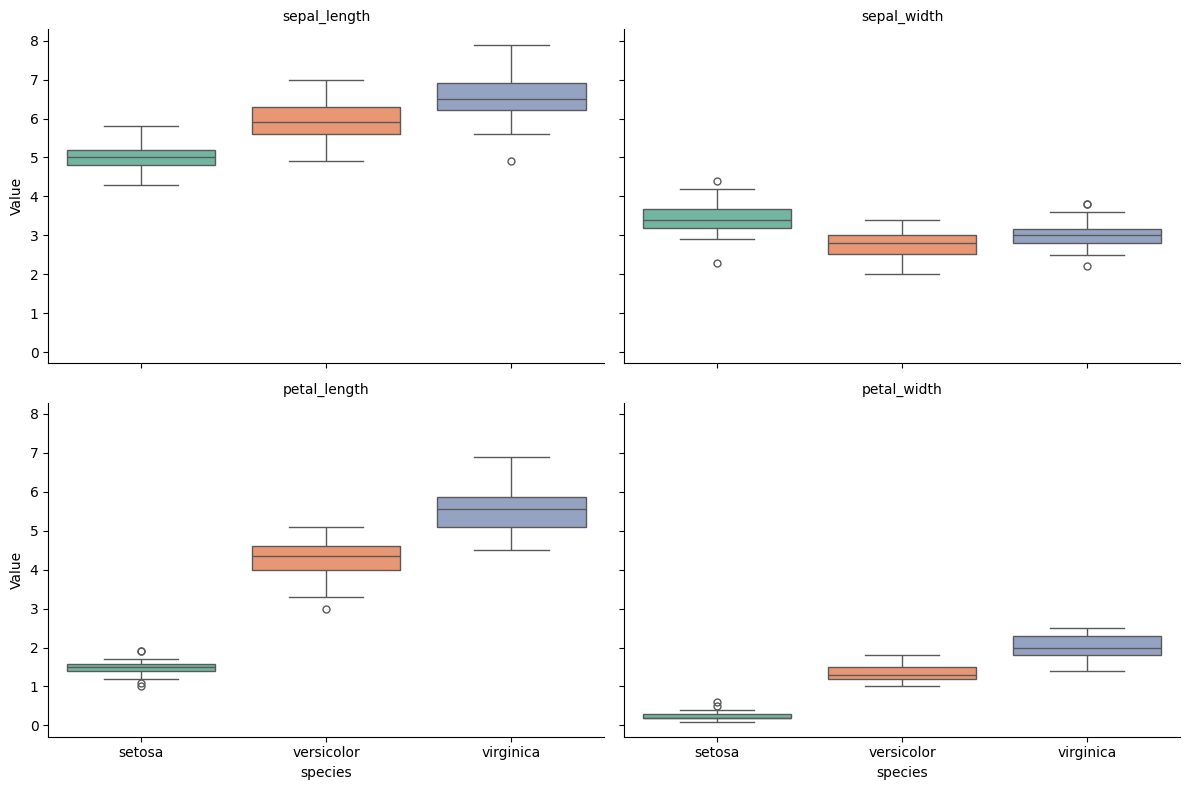

In [44]:
species_long = df.melt(id_vars="species", value_vars=var_col, var_name="Variable",value_name='Value')
species_color = sns.color_palette("Set2", n_colors=len(var_col))
species_palettes = dict(zip(species_long['species'].unique(), species_color))

var_box = sns.catplot(
    data=species_long,
    x='species',
    y='Value',
    col='Variable',
    col_wrap=2,
    kind='box',
    hue='species',
    palette=species_palettes,
    height=4,
    aspect=1.5,
)

var_box.set_titles("{col_name}")
plt.show()

### Generate sample from normal distribution and compare with real data

Now, let's generate synthetic data for each numerical variable based on its mean and standard deviation, assuming a normal distribution. We'll then compare the histogram of the real data with the theoretical Probability Density Function (PDF) of the generated normal distribution.

/tmp/ipykernel_2711/2315682576.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(x, pdf, 'r', color=palettes['sepal_width'], label='Theoretical PDF')


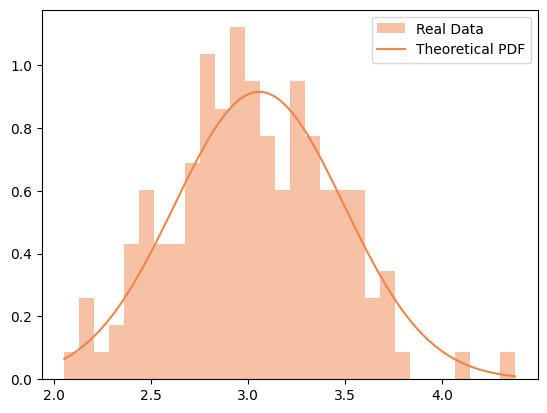

In [43]:
sample_mean = df['sepal_width'].mean()
sample_std = df['sepal_width'].std()
sample_test = np.random.normal(sample_mean, sample_std, len(df['sepal_width']))

plt.hist(
    sample_test,
    bins=30,
    density=True,
    color=palettes['sepal_width'],
    alpha=0.5,
    label='Real Data'
)

x = np.linspace(min(sample_test), max(sample_test), 100)
pdf = norm.pdf(x, sample_mean, sample_std)

plt.plot(x, pdf, 'r', color=palettes['sepal_width'], label='Theoretical PDF')
plt.legend()
plt.show()

As the center area, goodness of fit is high.

In [33]:
cov_matrix = df[var_col].cov()
cov_matrix

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006


In [ ]:
corr_matrix = df[var_col].corr()
corr_matrix

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


<Axes: >

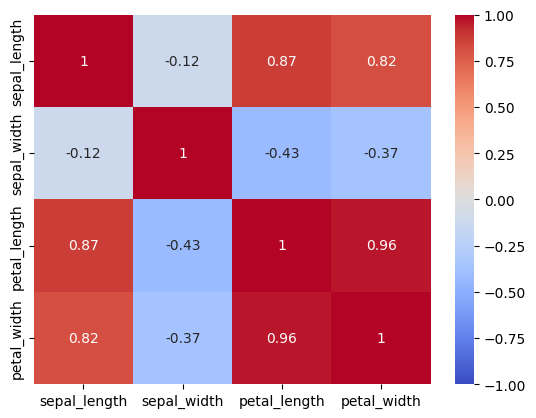

In [ ]:
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

The strongest corelation is the petal_length and petal_width couple

The second and third strongest corelation is (sepal_length, petal_length) and (sepal_lengh, petal_width) respectively

In [ ]:
# Check Multicollinearity
vif = np.diag(np.linalg.inv(corr_matrix))
vif_df = pd.DataFrame(vif, index=corr_matrix.columns, columns=['VIF'])
vif_df

,VIF
sepal_length,7.072722
sepal_width,2.100872
petal_length,31.261498
petal_width,16.090175


petal_length, petal_length is certainly multilinearity

sepal_length is  normally multilinearity


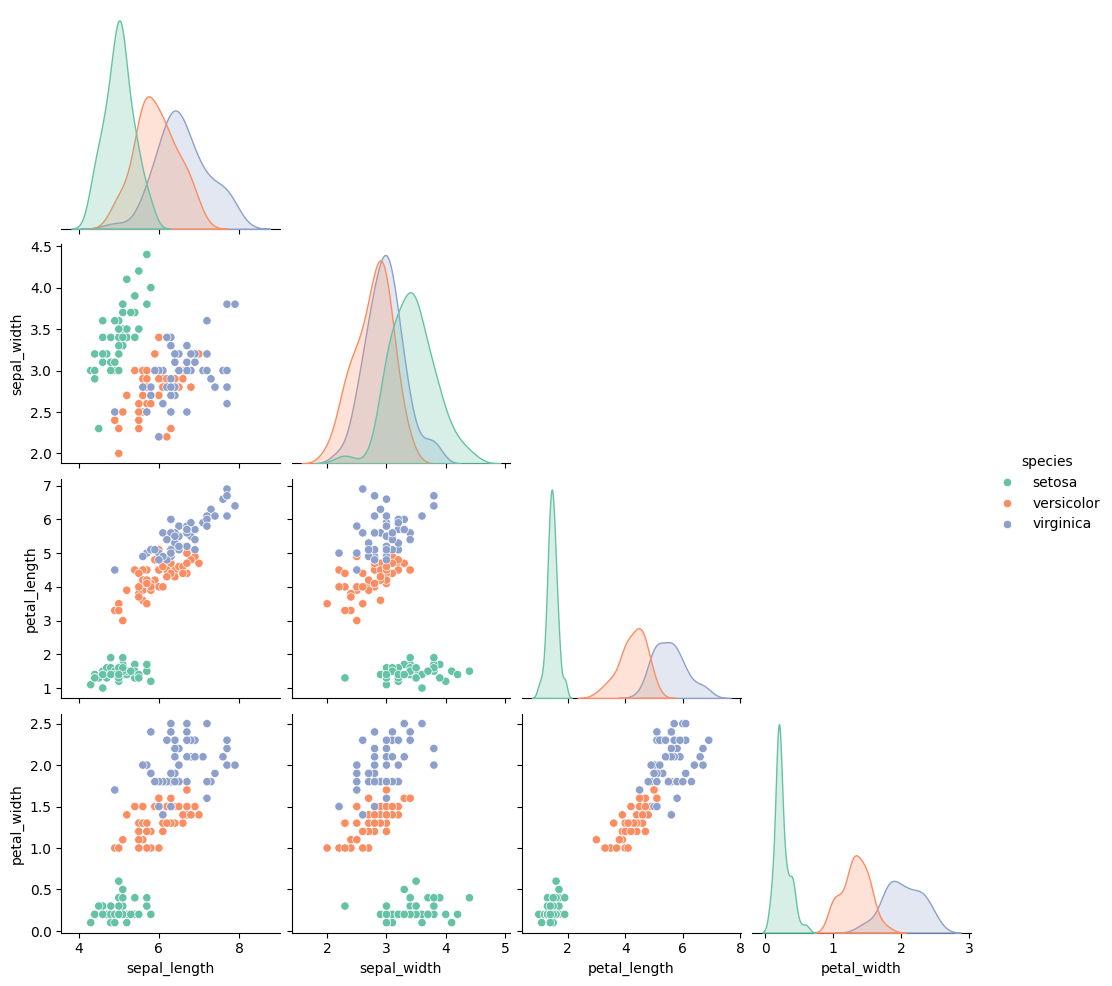

In [45]:
sns.pairplot(
    df,
    vars=var_col,
    diag_kind='kde',
    corner=True,
    hue='species',
    palette=species_palettes
)

plt.show()

## Pairplot Diagram Comments and Conclusion

*   **Petal Length and Petal Width:** These distributions clearly show three distinct peaks, indicating a strong separation between the three species based on these two features.

*   **Strong Linear Relationships:** There are clear positive linear relationships between `petal_length` and `petal_width`, `sepal_length` and `petal_length`, and `sepal_length` and `petal_width`. This confirms the high correlations observed in the correlation matrix.
*   **Species Separation:**
    *   The *setosa* species (often purple/blue dots) is almost perfectly separable from the other two species across all pairs of features, especially `petal_length` and `petal_width`.
    *   *Versicolor* and *virginica* (often orange and green dots) show some overlap, particularly in `sepal_length` vs. `sepal_width`. However, they are more distinctly separated when considering `petal_length` and `petal_width`, where *virginica* generally has larger petal dimensions than *versicolor*.

# Excercis 5

In [46]:
P_B      = 0.01
P_pos_B  = 0.99
P_pos_NB = 0.05
P_pos    = P_pos_B * P_B + P_pos_NB * (1 - P_B)
P_B_pos  = P_pos_B * P_B / P_pos
print (P_B_pos)

0.16666666666666669


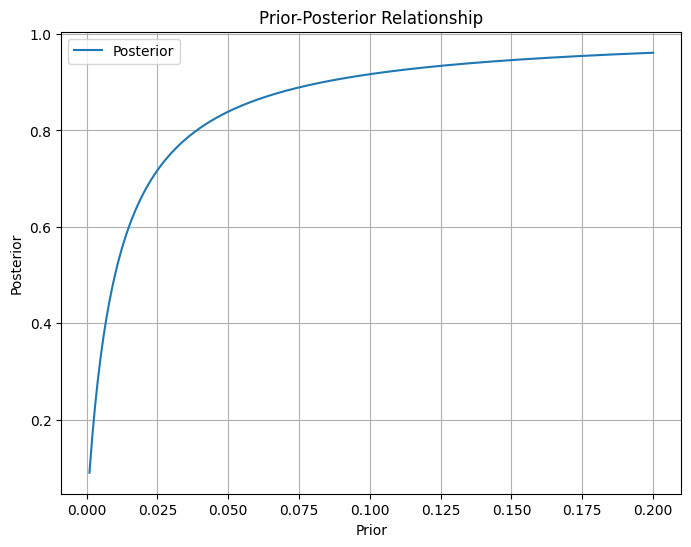

In [47]:
sensitivity = 0.99
false_positive = 0.05

prior = np.linspace(0.001, 0.2, 200)
posterior = (
    sensitivity * prior /
    (sensitivity * prior + (1 - sensitivity) * (1 - prior))
)

plt.figure(figsize=(8, 6))
plt.plot(prior, posterior, label='Posterior')
plt.xlabel('Prior')
plt.ylabel('Posterior')
plt.title('Prior-Posterior Relationship')
plt.legend()
plt.grid(True)
plt.show()

When P(B) is small, P(+|B) small although the sensitivity is 99%

When P(B) increases, P(B|+) approximates 1

P(B|+) = 0.167
=> The impact of Base rate

In [52]:
# Prior
p_spam = 0.4
p_ham = 0.6

spam_prob = {
    "free":0.8,
    "win":0.7,
    "meeting":0.1
}

ham_prob = {
    "free":0.05,
    "win":0.02,
    "meeting":0.6
}

In [51]:
def naive_bayes(email_word):
  spam = p_spam
  ham = p_ham
  for word in email_word:
    if word in spam_prob:
      spam *= spam_prob[word]
    if word in ham_prob:
      ham *= ham_prob[word]

  posterior = spam/(spam+ham)

  return posterior

In [56]:
print(naive_bayes("free"))
print(naive_bayes("win"))
print(naive_bayes(["win", "free"]))

0.4
0.4
0.9973285841495994
